In [2]:
import numpy
import matplotlib.pyplot as plt
import scipy
import pandas
import seaborn

print("All imports OK")
print(numpy.__file__)
print(plt.__file__)

All imports OK
/home/govind/gov_semproject/GridCellsTheta/GridCellsCond/.venv/lib/python3.13/site-packages/numpy/__init__.py
/home/govind/gov_semproject/GridCellsTheta/GridCellsCond/.venv/lib/python3.13/site-packages/matplotlib/pyplot.py


In [73]:
#input parameters. specify everything here.

theta_status = True #whether the inhitory conductance is theta modulated. 
theta_freq = 8.0

g_max = 0.0009
g_min = 0.00005
mod_depth = 0.1

tau_fall = 800.0 #ms. rate at which inhibition drops.
tau_rise = 400.0 #ms. rate at which inhibition rises.

dc_current = -1e-4 #inhibitory dc current to stellate cell. 

field_size = 4000 #ms
bw_field_size = 4000 #ms


In [74]:
from neuron import h
h.load_file('stdrun.hoc')
import numpy as np
import matplotlib.pyplot as plt
import stellate
import interneuron_amb
import importlib
importlib.reload(stellate)
h.celsius = 37.0
h.steps_per_ms = 40
h.dt = 0.025
h.cvode_active(0)

0.0

In [75]:
stellate_0 = stellate.Stellate(0)
interneuron_0 = interneuron_amb.Interneuron(0)

In [76]:
#simulation will have two fields. 
sim_dur = (2*bw_field_size) + (2*field_size)
num_steps = int(sim_dur/h.dt)
time_arr = np.arange(0,sim_dur,h.dt)
n_points = len(time_arr)

#separators
t_begin_1 = int(bw_field_size/2)
idx_begin_1 = int(t_begin_1/h.dt)
t_end_1 = t_begin_1 + int(field_size)
idx_end_1 = int(t_end_1/h.dt)

t_begin_2 = t_end_1 + int(bw_field_size)
idx_begin_2  = int(t_begin_2/h.dt)
t_end_2 = t_begin_2 + int(field_size)
idx_end_2 = int(t_end_2/h.dt)

#sections
t_field_1 = time_arr[idx_begin_1:idx_end_1] - time_arr[idx_begin_1]
t_bw_1 = time_arr[idx_end_1:idx_begin_2] - time_arr[idx_end_1]
t_field_2 = time_arr[idx_begin_2:idx_end_2] - time_arr[idx_begin_2]
t_bw_2 = time_arr[idx_end_2:] - time_arr[idx_end_2]

#inhibition envelope
inhib_base = np.full(n_points,g_max)
inhib_base[idx_begin_1:idx_end_1] = (g_max-g_min)*(np.exp(-t_field_1/tau_fall)) + g_min
start_val = inhib_base[idx_end_1-1]
inhib_base[idx_end_1:idx_begin_2] = (start_val + (g_max-start_val)*(1-np.exp(-t_bw_1/tau_rise)))
inhib_base[idx_begin_2:idx_end_2] = (g_max-g_min)*(np.exp(-t_field_2/tau_fall)) + g_min
start_val = inhib_base[idx_end_2-1]
inhib_base[idx_end_2:] = (start_val + (g_max-start_val)*(1-np.exp(-t_bw_2/tau_rise)))

#theta modulation
init_phase = np.random.uniform(0,2*np.pi)
theta_factor = 1 + (mod_depth*(np.sin(init_phase+(2*np.pi*theta_freq*time_arr/1000.0))))

if theta_status:
    inhib_cond_arr = theta_factor * inhib_base
else:
    inhib_cond_arr = inhib_base

noise = np.random.normal(loc=0.0,scale=1e-5,size=len(time_arr))

inhib_cond_arr += noise
inhib_cond_arr = np.maximum(inhib_cond_arr,0.00001)


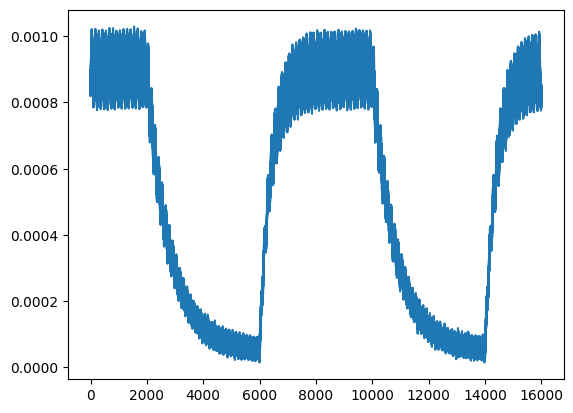

In [77]:
plt.plot(time_arr,inhib_cond_arr)

In [78]:

#inputs to stellate cell

stell_ic = h.IClamp(stellate_0.soma(0.5))
stell_ic.dur = 1e9
dc_val = -2.7e-4
inhib_dc = np.full(n_points,dc_val,dtype=np.float64)
stell_dc_vec = h.Vector(inhib_dc)
stell_dc_vec.play(stell_ic._ref_amp,h.dt)

#inhibitory synapse

syn_inh = h.ExpSyn(stellate_0.soma(0.5))
syn_inh.e = -80
syn_inh.tau = 10.0

g_vec = h.Vector(inhib_cond_arr)
g_vec.play(syn_inh._ref_g, h.dt)

#recorders

stell_v = h.Vector().record(stellate_0.soma(0.5)._ref_v)
stellate_gh_vec = h.Vector().record(stellate_0.soma(0.5).stellate_mech._ref_gh)
g_rec = h.Vector().record(syn_inh._ref_g)

nc_stell = h.NetCon(stellate_0.soma(0.5)._ref_v, None, sec=stellate_0.soma)
nc_stell.threshold = 0
spike_times_stell = h.Vector()
nc_stell.record(spike_times_stell)
time = h.Vector().record(h._ref_t)



In [79]:
h.finitialize(-80)
h.frecord_init()
h.continuerun(sim_dur)

0.0

In [80]:
#phase extraction

spikes_arr = np.array(spike_times_stell.to_python())
phases = ((init_phase+((spikes_arr) * theta_freq * 2 * np.pi / 1000)) % (2 * np.pi))
phases_shifted = phases + 2*np.pi

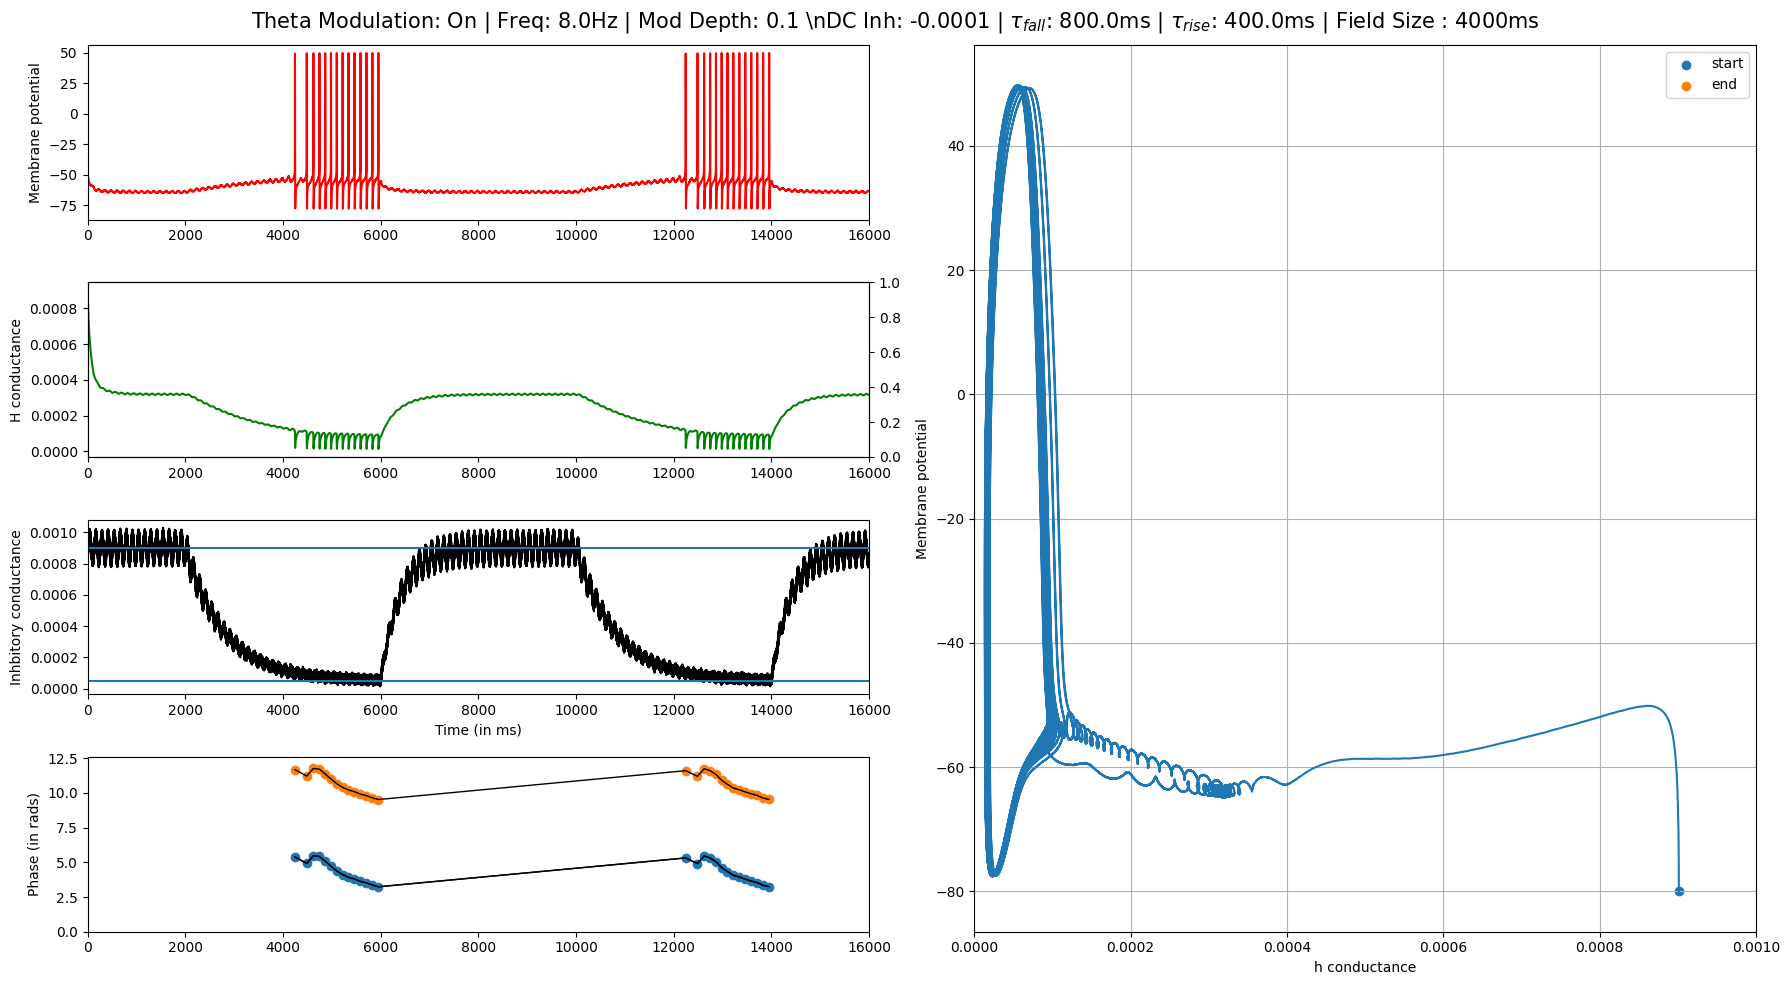

In [81]:
#plotting

from matplotlib.gridspec import GridSpec

gh_cond = stellate_gh_vec.to_python()
memb_pot = stell_v.to_python()
start_time = 0
end_time =  sim_dur
start_idx = int(start_time/h.dt)
end_idx = int(end_time/h.dt)

fig = plt.figure(figsize=(18,10))

gs = GridSpec(4,2,width_ratios=[1,1])
ax0 = fig.add_subplot(gs[0,0])
ax1 = fig.add_subplot(gs[1,0])
ax1_1 = ax1.twinx()
ax2 = fig.add_subplot(gs[2,0])
ax3 = fig.add_subplot(gs[3,0])

ax_phase = fig.add_subplot(gs[:,1])


ax1.plot(time_arr[start_idx:end_idx],gh_cond[start_idx:end_idx],color='green')
ax2.set_xlabel("Time (in ms)")
ax2.set_ylabel("Inhbitory conductance")
ax1.set_ylabel("H conductance")
#ax1_1.plot(time_arr[start_idx:end_idx],gnap_cond[start_idx:end_idx],color='purple')
ax0.set_ylabel("Membrane potential")
ax0.plot(time_arr[start_idx:end_idx],memb_pot[start_idx:end_idx],color='red')
ax2.plot(time_arr[start_idx:end_idx],inhib_cond_arr[start_idx:end_idx],color='black')
ax2.axhline(y=g_max)
ax3.plot(spikes_arr,phases,linewidth=1,color='black')
ax2.axhline(y=g_min)
ax3.plot(spikes_arr,phases,linewidth=1,color='black')
ax3.plot(spikes_arr,phases_shifted,linewidth=1,color='black')
ax3.scatter(spikes_arr,phases)
ax3.scatter(spikes_arr,phases_shifted)
ax3.set_ylabel("Phase (in rads)")
ax3.set_ylim(0,4*np.pi)
ax_phase.plot(gh_cond[start_idx:end_idx],memb_pot[start_idx:end_idx])
ax_phase.scatter(gh_cond[start_idx],memb_pot[start_idx],label='start')
ax_phase.scatter(gh_cond[end_idx],memb_pot[end_idx],label='end')
ax_phase.legend()
ax_phase.set_xlabel("h conductance")
ax_phase.set_ylabel("Membrane potential")
ax_phase.set_xlim(0,0.001)
ax0.set_xlim(start_time,end_time)
ax1.set_xlim(start_time,end_time)
ax2.set_xlim(start_time,end_time)
ax3.set_xlim(start_time,end_time)

theta_status_str = "On" if theta_status else 'Off'
plt.suptitle(f"Theta Modulation: {theta_status_str} | Freq: {theta_freq}Hz | Mod Depth: {mod_depth} \\n"
             f"DC Inh: {dc_current} | $\\tau_{{fall}}$: {tau_fall}ms | $\\tau_{{rise}}$: {tau_rise}ms | Field Size : {field_size}ms", 
             fontsize=15)
plt.grid(True)
plt.tight_layout()
plt.show()



